In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/q3_retail_promotions.csv')
df.head()


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [13]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


We extracted year, month, and day of week from the transaction date. We also created a new feature to identify month-end periods.


In [14]:
df = df.sort_values('transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']


We used a time-based split instead of random split because the data is time-dependent. This prevents data leakage and ensures realistic model evaluation.


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Regression
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

# Random Forest
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

# Metrics
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))


Linear Regression RMSE: 27.121451164890622
Linear Regression MAE: 21.052926674588395
Random Forest RMSE: 31.658897860633115
Random Forest MAE: 24.904708333333335


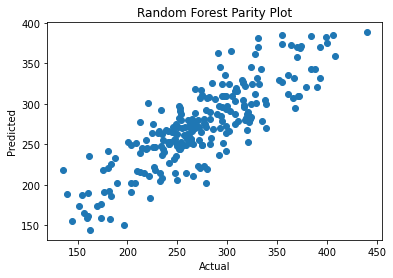

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Parity Plot")
plt.show()


In [19]:
model = rf_pipeline.named_steps['model']
importances = model.feature_importances_

feature_names = numerical_cols + list(
    rf_pipeline.named_steps['preprocessor']
    .transformers_[1][1]
    .get_feature_names_out(categorical_cols)
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df.head(5)


,feature,importance
15,store_size_small,0.183953
2,is_festival,0.174490
13,location_type_urban,0.140494
6,day_of_week,0.087179
1,is_weekend,0.066870


The top features influencing sales include promotion type, store size, and competition density.
